In [71]:
# this is some set-up stuff i stole from HW2 to make things reproducible 
# and so i have an environment to reuse a bunch of my code


# If you are running in a fresh environment, uncomment to install dependencies:
#!pip -q install torch torchvision matplotlib tqdm scikit-learn numpy

import os
import platform
if platform.system() == "Windows":
    import ctypes
    from importlib.util import find_spec
    try:
        if (spec := find_spec("torch")) and spec.origin and os.path.exists(
            dll_path := os.path.join(os.path.dirname(spec.origin), "lib", "c10.dll")
        ):
            ctypes.CDLL(os.path.normpath(dll_path))
    except Exception:
        pass
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, DataLoader, random_split

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)

torch: 2.8.0+cpu
device: cpu


In [72]:
# i don't have a graphics card...
torch.cuda.is_available()

False

In [194]:
# make custom dataset for train
import pandas as pd
import csv
from torchvision.io import read_image 

batch_size = 64
num_workers = 0

# make annotations file for train dataset by walking thru directory
# and writing a csv w/ each image and what label folder they're in
with open("./out/test_labels.csv", mode="w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["ID","Label"])
    labels = os.listdir("./data/train")
    for i in range(len(labels)):
        for img in os.listdir(os.path.join("./data/train", labels[i])):
            writer.writerow([img, labels[i]])

# from intro to pytorch lecture slides
class CustomImageTrainData(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, f'{self.img_labels.iloc[index,1]}', self.img_labels.iloc[index,0])
        image = read_image(img_path)
        label = self.img_labels.iloc[index,1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        sample = {"image": image, "label": label}
        return sample

full_train_dataset = CustomImageTrainData("./out/test_labels.csv", "./data/train", 
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(size=(256, 256), antialias=True),
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    target_transform=transforms.Compose([
        transforms.ToDtype(torch.float32)
    ])
)
print(len(full_train_dataset))


1079


863 216


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].


Feature batch shape: torch.Size([64, 3, 256, 256])
Labels batch shape: torch.Size([64])
Label: 53


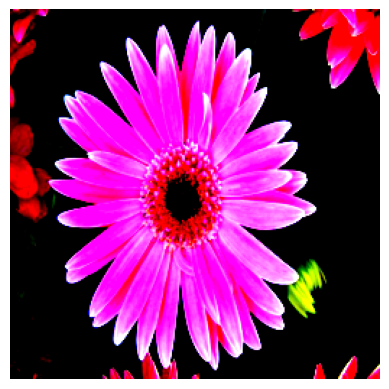

In [212]:
# split dataset and set up dataloaders for train/val, verify is working
import math

train_set, val_set = random_split(full_train_dataset, [math.floor(len(full_train_dataset)*0.8), (len(full_train_dataset) - math.floor(len(full_train_dataset)*0.8))])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
print(len(train_set), len(val_set))


sample = next(iter(train_loader))
train_features = sample["image"]
train_labels = sample["label"]
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
print(f"Label: {label}")
img = train_features[0].numpy().transpose(1, 2, 0)
label = train_labels[0]
plt.imshow(img)
plt.axis("off")
plt.show()
